# Grad-CAM Under Attack: Where Is the Model Actually Looking?

`latent_space/` shows *how far* an adversarial perturbation pushes an image's internal representation, and `loss_landscape_3d/` shows the terrain the attack climbs to get there. This notebook asks a more visual, more immediate question: **where in the image is the model actually looking when it makes its (now wrong) decision?**

**Grad-CAM** (Selvaraju et al., 2017, *"Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization"*) answers that by weighting the last convolutional feature map by how much each channel matters for the predicted class:
$$L^c_{Grad\text{-}CAM} = \mathrm{ReLU}\Big( \sum_k \alpha_k^c \, A^k \Big), \qquad \alpha_k^c = \frac{1}{Z}\sum_{i,j} \frac{\partial y^c}{\partial A^k_{ij}}
$$
where $A^k$ is the $k$-th feature map of the last convolutional layer and $\alpha_k^c$ its importance for class $c$, obtained by global-average-pooling the gradient of the class score $y^c$ with respect to that feature map. We compute this **before and after** an FGSM/PGD attack, using the *same* target class (the original, correct one) both times, so any shift in the heatmap is attributable to the attack, not to a different question being asked of the model.


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from tensorflow.keras.applications import EfficientNetB0, InceptionV3, MobileNetV2
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff, decode_predictions as decode_eff
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inc, decode_predictions as decode_inc
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mob, decode_predictions as decode_mob

### Setup
Same `models_dict` / `images_dict` convention as `attacks/*.ipynb`. `gradcam_layer` names the last convolutional activation of each architecture, the feature map Grad-CAM reads from: after this point the network only has global pooling and a dense classification head left, no more spatial structure to visualize.

In [2]:
# Helper functions for denormalization based on model preprocessing
def denormalize_eff(img):
    img = tf.clip_by_value(img, 0, 255)
    return img.numpy().squeeze().astype("uint8")

def denormalize_neg1_1(img):
    img = (img + 1.0) / 2.0
    img = img * 255.0
    img = tf.clip_by_value(img, 0, 255)
    return img.numpy().squeeze().astype("uint8")

models_dict = {
    'MobileNetV2': {
        'model': MobileNetV2(weights='imagenet'),
        'target_size': (224, 224), 'preprocess_fn': preprocess_mob, 'decode_fn': decode_mob,
        'denormalize_fn': denormalize_neg1_1, 'clip_min': -1.0, 'clip_max': 1.0,
        'gradcam_layer': 'out_relu',
    },
    'EfficientNetB0': {
        'model': EfficientNetB0(weights='imagenet'),
        'target_size': (224, 224), 'preprocess_fn': preprocess_eff, 'decode_fn': decode_eff,
        'denormalize_fn': denormalize_eff, 'clip_min': 0.0, 'clip_max': 255.0,
        'gradcam_layer': 'top_activation',
    },
    'InceptionV3': {
        'model': InceptionV3(weights='imagenet'),
        'target_size': (299, 299), 'preprocess_fn': preprocess_inc, 'decode_fn': decode_inc,
        'denormalize_fn': denormalize_neg1_1, 'clip_min': -1.0, 'clip_max': 1.0,
        'gradcam_layer': 'mixed10',
    },
}

for config in models_dict.values():
    config['model'].trainable = False

images_dict = {
    'Dog': '../images/dog.png',
    'Lion': '../images/lion.png',
}

In [3]:
def load_and_preprocess_image(img_path, target_size, preprocess_fn):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, target_size)
    img = preprocess_fn(img)
    return tf.expand_dims(img, axis=0)

def get_imagenet_class_index(prob):
    return int(tf.argmax(prob, axis=-1).numpy()[0])

### Grad-CAM and the Attack
`fgsm_attack`/`pgd_attack` are the same implementations used throughout the repo. `gradcam` builds a temporary model exposing both the target conv layer's activations and the final predictions, so a single `GradientTape` pass yields everything needed.

In [4]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

def fgsm_attack(img, label, epsilon, model, clip_min, clip_max):
    with tf.GradientTape() as tape:
        tape.watch(img)
        pred = model(img, training=False)
        loss = loss_object(label, pred)
    grad = tape.gradient(loss, img)
    return tf.clip_by_value(img + epsilon * tf.sign(grad), clip_min, clip_max)

def pgd_attack(img, label, epsilon, model, clip_min, clip_max, iters=10):
    alpha = epsilon / (iters / 2.0)
    adv_img = tf.identity(img)
    for _ in range(iters):
        with tf.GradientTape() as tape:
            tape.watch(adv_img)
            pred = model(adv_img, training=False)
            loss = loss_object(label, pred)
        grad = tape.gradient(loss, adv_img)
        adv_img = adv_img + alpha * tf.sign(grad)
        perturbation = tf.clip_by_value(adv_img - img, -epsilon, epsilon)
        adv_img = tf.clip_by_value(img + perturbation, clip_min, clip_max)
    return adv_img

def gradcam(img, model, layer_name, class_idx):
    """Grad-CAM (Selvaraju et al., 2017) heatmap for `class_idx`, resized to the input's spatial size."""
    grad_model = tf.keras.Model(model.inputs, [model.get_layer(layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(img, training=False)
        class_score = preds[:, class_idx]

    grads = tape.gradient(class_score, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # alpha_k^c

    heatmap = tf.reduce_sum(conv_output[0] * pooled_grads, axis=-1)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    heatmap = tf.image.resize(heatmap[..., tf.newaxis], (img.shape[1], img.shape[2]))
    return heatmap.numpy().squeeze()

def overlay_heatmap(base_image_uint8, heatmap, alpha=0.4):
    """Blends a Grad-CAM heatmap (jet colormap) onto a denormalized uint8 RGB image."""
    heatmap_colored = cm.jet(heatmap)[..., :3] * 255.0
    overlay = (1 - alpha) * base_image_uint8.astype(np.float32) + alpha * heatmap_colored
    return np.clip(overlay, 0, 255).astype(np.uint8)

### Evaluation Loop
For each model and image: Grad-CAM on the clean prediction, generate a PGD adversarial example ($\varepsilon = 0.05$), then Grad-CAM again **for the same original class** on the now-misclassified adversarial image. A model attacked into confidence about the wrong class, while its attention map barely moves, is being fooled locally (a small nudge across a nearby decision boundary); a model whose attention map jumps to a completely different region is being fooled by exploiting an entirely different, spurious feature.


GRAD-CAM UNDER ATTACK - MODEL: MobileNetV2


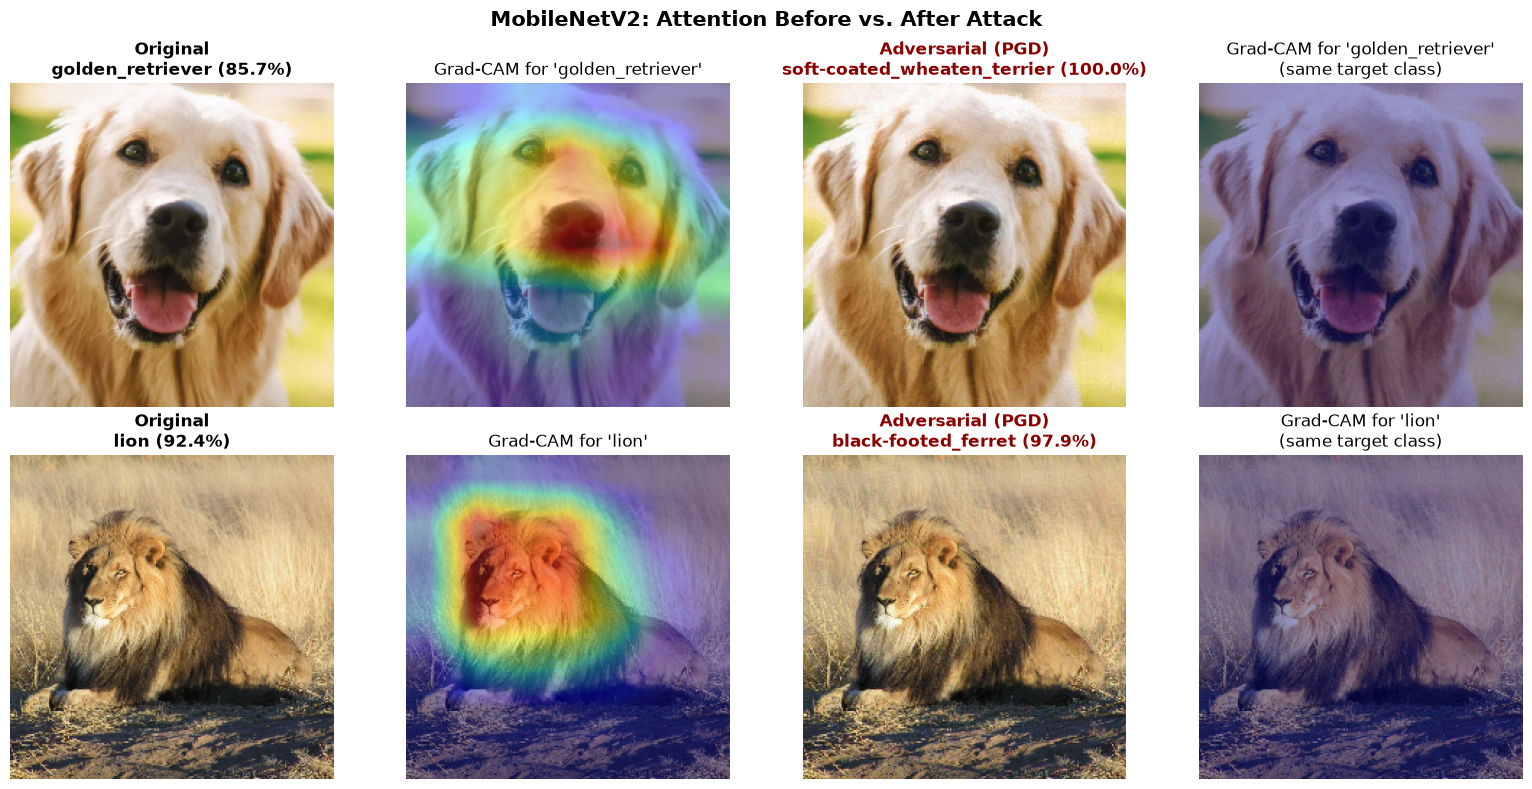


GRAD-CAM UNDER ATTACK - MODEL: EfficientNetB0


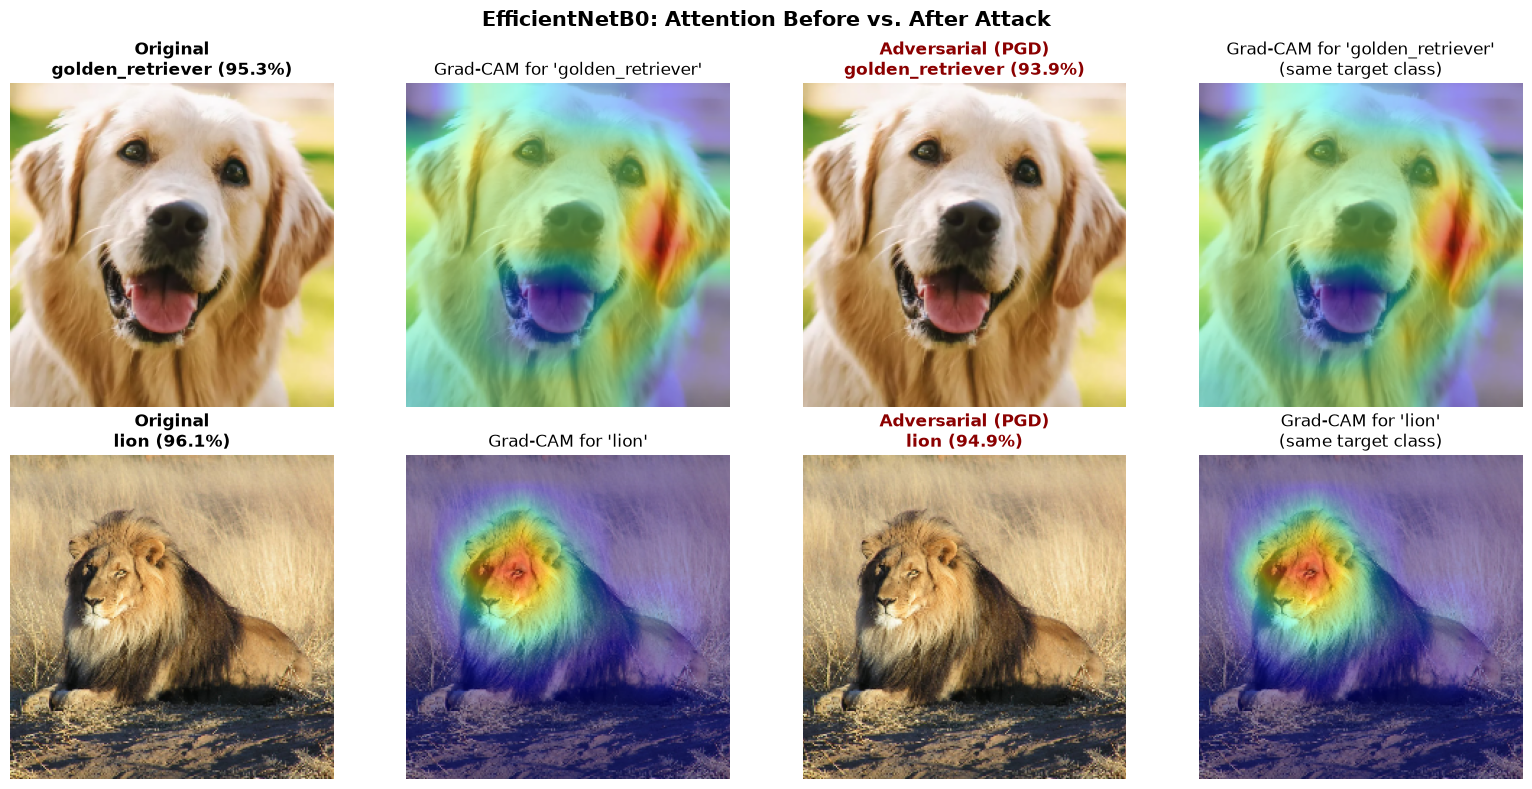


GRAD-CAM UNDER ATTACK - MODEL: InceptionV3


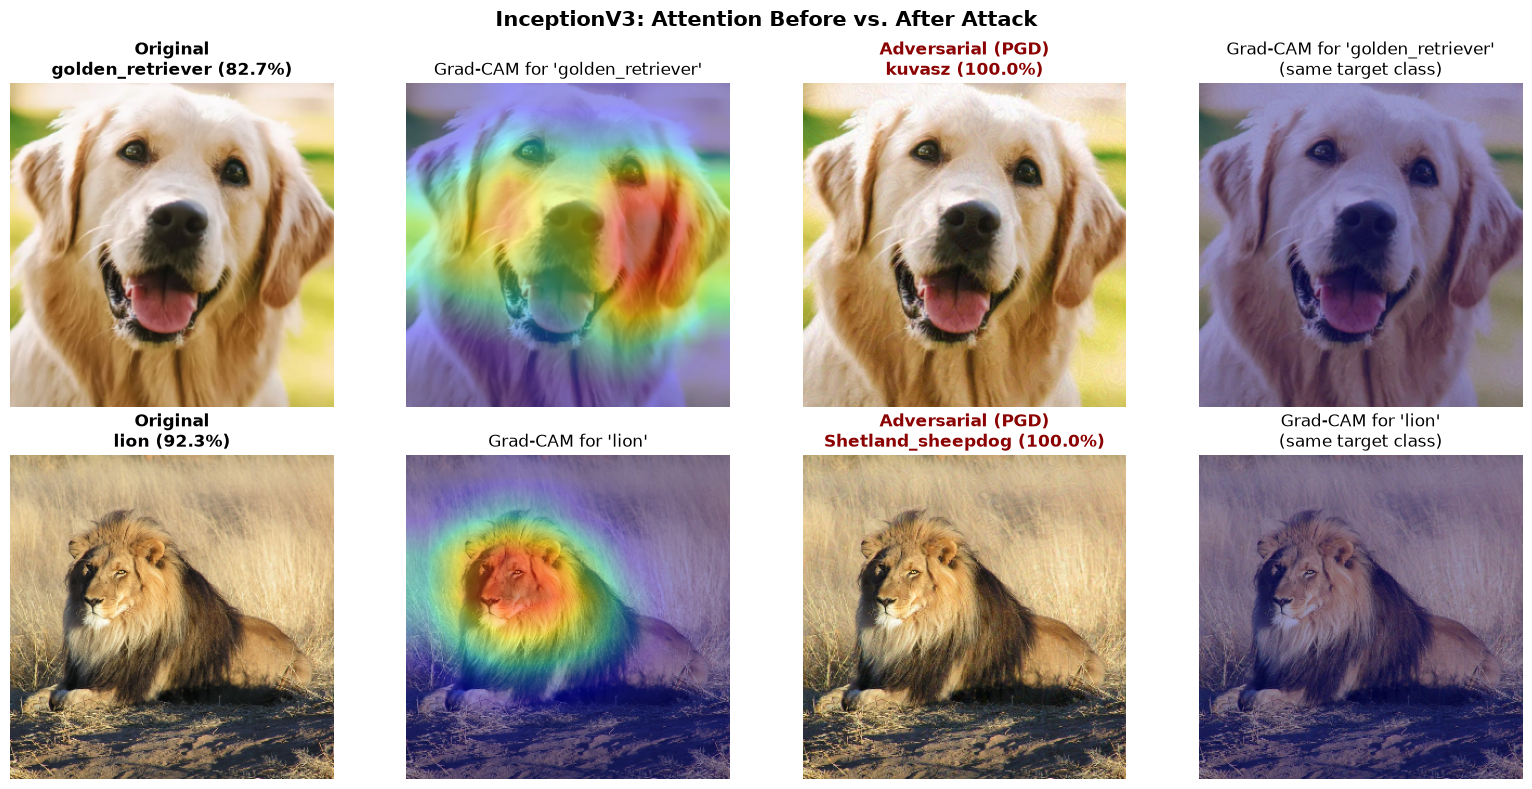

In [5]:
BASE_EPSILON = 0.05

for model_name, m_config in models_dict.items():
    print(f"\n{'='*80}\nGRAD-CAM UNDER ATTACK - MODEL: {model_name}\n{'='*80}")

    current_model = m_config['model']
    target_size = m_config['target_size']
    preprocess_fn = m_config['preprocess_fn']
    decode_fn = m_config['decode_fn']
    denormalize_fn = m_config['denormalize_fn']
    clip_min, clip_max = m_config['clip_min'], m_config['clip_max']
    layer_name = m_config['gradcam_layer']

    fig, axes = plt.subplots(len(images_dict), 4, figsize=(16, 4 * len(images_dict)))

    for row, (img_name, img_path) in enumerate(images_dict.items()):
        input_img = load_and_preprocess_image(img_path, target_size, preprocess_fn)

        original_probs = current_model.predict(input_img, verbose=0)
        true_idx = get_imagenet_class_index(original_probs)
        _, orig_class_name, orig_prob = decode_fn(original_probs, top=1)[0][0]
        input_label = tf.reshape(tf.one_hot(true_idx, original_probs.shape[-1]), (1, -1))

        adv_img = pgd_attack(input_img, input_label, BASE_EPSILON, current_model, clip_min, clip_max, iters=10)
        adv_probs = current_model.predict(adv_img, verbose=0)
        adv_idx = get_imagenet_class_index(adv_probs)
        _, adv_class_name, adv_prob = decode_fn(adv_probs, top=1)[0][0]

        clean_heatmap = gradcam(input_img, current_model, layer_name, true_idx)
        adv_heatmap = gradcam(adv_img, current_model, layer_name, true_idx)  # same target class both times

        clean_uint8 = denormalize_fn(input_img)
        adv_uint8 = denormalize_fn(adv_img)

        axes[row, 0].imshow(clean_uint8)
        axes[row, 0].set_title(f'Original\n{orig_class_name} ({orig_prob*100:.1f}%)', fontweight='bold')
        axes[row, 1].imshow(overlay_heatmap(clean_uint8, clean_heatmap))
        axes[row, 1].set_title(f"Grad-CAM for '{orig_class_name}'")
        axes[row, 2].imshow(adv_uint8)
        axes[row, 2].set_title(f'Adversarial (PGD)\n{adv_class_name} ({adv_prob*100:.1f}%)', fontweight='bold', color='darkred')
        axes[row, 3].imshow(overlay_heatmap(adv_uint8, adv_heatmap))
        axes[row, 3].set_title(f"Grad-CAM for '{orig_class_name}'\n(same target class)")

        for col in range(4):
            axes[row, col].axis('off')

    plt.suptitle(f'{model_name}: Attention Before vs. After Attack', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()